# Classical Markowitz VS Quantum MArkowitz 

## Preprocessing Part

---
### 1.1 Imports & Configuration

In [1]:
import csv, warnings, time
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import cvxpy as cp

# ── Constants ─────────────────────────────────────────────────────
RISK_FREE = 0.02    # annual risk-free rate (US T-bill proxy)
BUDGET    = 10      # number of assets to select
LAMBDA    = 0.5     # risk-return trade-off  (0=max return, 1=min risk)
CSV_FILE  = 'combined_close_prices.csv'
print("GIVEN DATA: ")
print(f"Risk-free rate : {RISK_FREE*100:.1f}%  (annual)")
print(f"Budget K       : {BUDGET} assets")
print(f"Lambda λ       : {LAMBDA}  (equal risk-return balance)")


GIVEN DATA: 
Risk-free rate : 2.0%  (annual)
Budget K       : 10 assets
Lambda λ       : 0.5  (equal risk-return balance)


---
### 1.2 Load Data & Compute Returns

In [2]:
# ── Load CSV using standard library (no pandas dependency) ────────
import numpy as np
with open(CSV_FILE) as f:
    rows    = list(csv.reader(f))
headers     = rows[0]
TICKERS     = headers[1:]                          # 40 asset names
dates       = [r[0] for r in rows[1:]]
price_data  = np.array([[float(v) for v in r[1:]]
                         for r in rows[1:]], dtype=float)

N = len(TICKERS)    # 40 assets
T = len(dates)      # 2765 trading days

print(f"Assets         : {N}")
print(f"Trading days   : {T}")
print(f"Date range     : {dates[0]}  →  {dates[-1]}")
print(f"Tickers        : {', '.join(TICKERS)}")


Assets         : 40
Trading days   : 2765
Date range     : 2015-01-02  →  2025-12-30
Tickers        : AAPL, ABBV, ACN, ADBE, AMD, AMZN, AVGO, BAC, BRK-B, COST, CRM, CSCO, CVX, DHR, GOOGL, HD, INTC, JNJ, JPM, KO, LIN, LLY, MA, MCD, META, MRK, MSFT, NFLX, NVDA, ORCL, PEP, PG, QCOM, TMO, TSLA, TXN, UNH, V, WMT, XOM


Log returns shape : (2764, 40)  (trading days × assets)
  μ  range : 0.0265  →  0.5435
  σ  range : 0.1783  →  0.5781
  Σ  shape : (40, 40)

PER-ASSET STATISTICS (40 assets, full history)
Ticker     Ann Ret%   Ann Vol%   Sharpe    Skew    Kurt
------------------------------------------------------------------------
NVDA         54.35%     48.36%    1.083   0.136   6.921
LLY          26.74%     29.06%    0.851   0.311  10.734
AVGO         34.96%     38.98%    0.846  -0.074  10.560
MSFT         22.83%     26.86%    0.775  -0.097   8.148
COST         18.47%     21.63%    0.762  -0.504   8.791
GOOGL        22.61%     28.78%    0.716   0.038   5.843
AAPL         22.08%     28.82%    0.697  -0.089   6.350
AMZN         24.73%     32.80%    0.693   0.171   5.793
AMD          40.03%     57.81%    0.658   0.577  10.030
MA           18.01%     26.32%    0.608  -0.038   9.278
JPM          17.64%     27.11%    0.577  -0.078  13.028
V            15.97%     24.24%    0.576  -0.100   9.641
WMT        

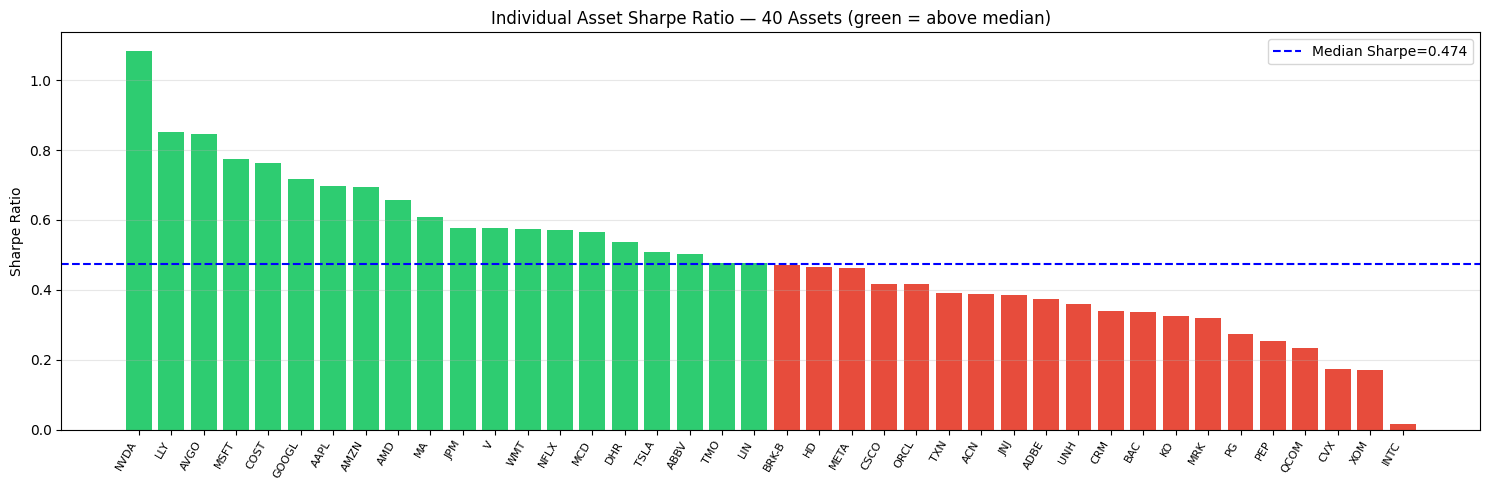

In [3]:
# ── Log returns: r_t = ln(P_t / P_{t-1}) ─────────────────────────
log_ret = np.diff(np.log(price_data), axis=0)   # shape (T-1, N)

# ── Annualised statistics ──────────────────────────────────────────
mu    = log_ret.mean(axis=0) * 252               # expected annual return
sigma = log_ret.std(axis=0)  * np.sqrt(252)      # annual volatility  (1D)
cov   = np.cov(log_ret.T)    * 252               # annual covariance (N×N)

print(f"Log returns shape : {log_ret.shape}  (trading days × assets)")
print(f"  μ  range : {mu.min():.4f}  →  {mu.max():.4f}")
print(f"  σ  range : {sigma.min():.4f}  →  {sigma.max():.4f}")
print(f"  Σ  shape : {cov.shape}")

# ── Per-asset statistics ───────────────────────────────────────────
import scipy.stats as stats_lib, os

OUT_DIR = '.'

ann_ret = mu                                       # already annualised (×252)
ann_vol = sigma                                    # already annualised (×√252)
sharpe  = (ann_ret - RISK_FREE) / ann_vol
skew_v  = stats_lib.skew(log_ret, axis=0)
kurt_v  = stats_lib.kurtosis(log_ret, axis=0)

print('\n' + '='*72)
print('PER-ASSET STATISTICS (40 assets, full history)')
print('='*72)
print(f"{'Ticker':<8} {'Ann Ret%':>10} {'Ann Vol%':>10} {'Sharpe':>8} {'Skew':>7} {'Kurt':>7}")
print('-'*72)
for i in np.argsort(sharpe)[::-1]:
    print(f"{TICKERS[i]:<8} {ann_ret[i]*100:>9.2f}% {ann_vol[i]*100:>9.2f}% "
          f"{sharpe[i]:>8.3f} {skew_v[i]:>7.3f} {kurt_v[i]:>7.3f}")

# Bar chart
sorted_idx = np.argsort(sharpe)[::-1]
fig, ax = plt.subplots(figsize=(15, 5))
colors = ['#2ecc71' if s > np.median(sharpe) else '#e74c3c' for s in sharpe[sorted_idx]]
ax.bar(range(N), sharpe[sorted_idx], color=colors)
ax.set_xticks(range(N))
ax.set_xticklabels([TICKERS[i] for i in sorted_idx], rotation=60, ha='right', fontsize=8)
ax.axhline(np.median(sharpe), color='blue', ls='--', lw=1.5,
           label=f'Median Sharpe={np.median(sharpe):.3f}')
ax.set_title('Individual Asset Sharpe Ratio — 40 Assets (green = above median)', fontsize=12)
ax.set_ylabel('Sharpe Ratio')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sharpe_all40.png'), dpi=130)
plt.show()

ASSET QUBO SCORE = −λ·μᵢ + (1−λ)·σᵢᵢ/2   at λ=0.5  (lower = more attractive to VQE)
Rank  Asset   λ=0.1        λ=0.3        λ=0.5        λ=0.7        λ=0.9          Decision@λ=0.5
------------------------------------------------------------------------------------------
[ 1]  NVDA       +0.050925    -0.081179    -0.213283    -0.345386    -0.477490   ✓ top-10
[ 2]  AVGO       +0.033423    -0.051695    -0.136813    -0.221931    -0.307049   ✓ top-10
[ 3]  AMD        +0.110437    -0.003051    -0.116539    -0.230027    -0.343515   ✓ top-10
[ 4]  LLY        +0.011271    -0.050660    -0.112591    -0.174522    -0.236452   ✓ top-10
[ 5]  AMZN       +0.023704    -0.036530    -0.096763    -0.156997    -0.217230   ✓ top-10
[ 6]  MSFT       +0.009650    -0.043225    -0.096100    -0.148975    -0.201850   ✓ top-10
[ 7]  GOOGL      +0.014680    -0.038831    -0.092342    -0.145854    -0.199365   ✓ top-10
[ 8]  AAPL       +0.015306    -0.037163    -0.089633    -0.142102    -0.194572   ✓ top-10
[ 9]  NFL

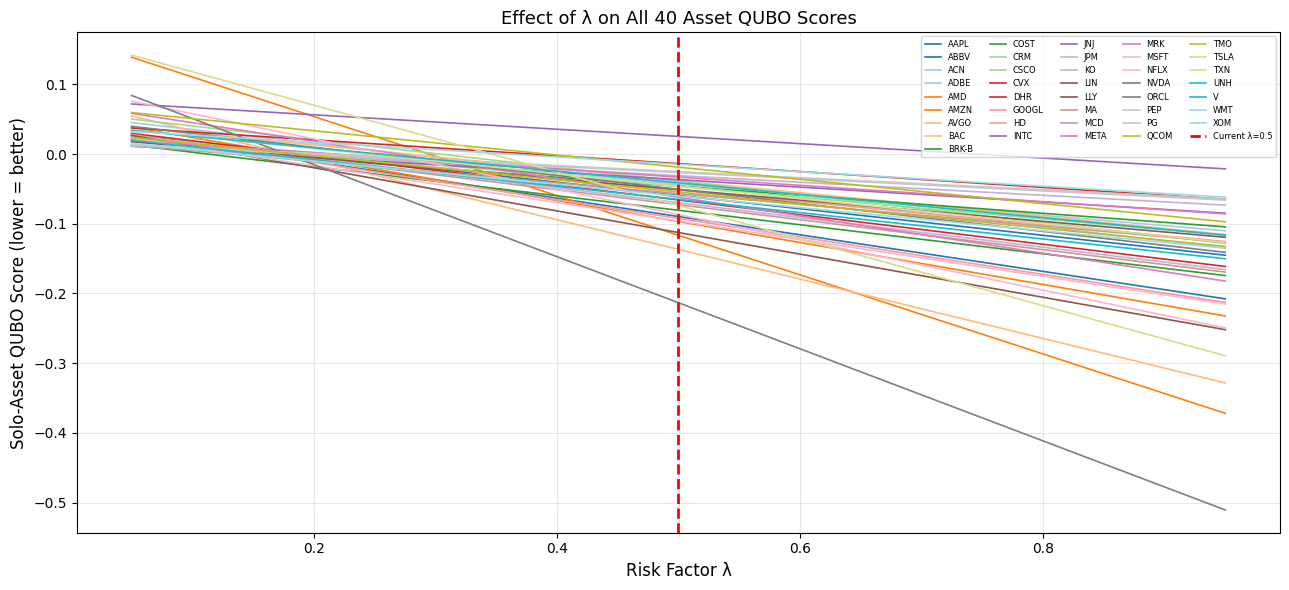

In [4]:
## QUBO asset scores across lambda values

PRE_SCREEN_N = 15   # pre-screen pool before VQE (must be > BUDGET)
lambdas = [0.1, 0.3, 0.5, 0.7, 0.9]

# σᵢᵢ = variance of asset i = diagonal of covariance matrix (cov is 2D, sigma is 1D std-dev)
scores_05 = np.array([-0.5*mu[i] + 0.5*cov[i,i]/2 for i in range(N)])

print('='*90)
print(f'ASSET QUBO SCORE = −λ·μᵢ + (1−λ)·σᵢᵢ/2   at λ=0.5  (lower = more attractive to VQE)')
print('='*90)
print(f'{"Rank":<6}{"Asset":<8}' + ''.join(f'{"λ="+str(l):<13}' for l in lambdas) + '  Decision@λ=0.5')
print('-'*90)
ranked_idx = np.argsort(scores_05)
for rank, i in enumerate(ranked_idx, 1):
    scores_row = [-l*mu[i] + (1-l)*cov[i,i]/2 for l in lambdas]
    decision = (f'✓ top-{BUDGET}' if rank <= BUDGET
                else ('◉ pre-screen' if rank <= PRE_SCREEN_N else '✗ discarded'))
    print(f'[{rank:2d}]  {TICKERS[i]:<8}' + ''.join(f'{s:+12.6f} ' for s in scores_row) + f'  {decision}')

print()
print('LEGEND:')
print(f'  ✓ top-{BUDGET}      : enters the final portfolio')
print(f'  ◉ pre-screen : passes pre-filter (ranks {BUDGET+1}–{PRE_SCREEN_N}); enters VQE universe')
print(f'  ✗ discarded  : too volatile or too low return at λ=0.5')

# Lambda sweep plot
fig, ax = plt.subplots(figsize=(13, 6))
lam_range = np.linspace(0.05, 0.95, 200)
cmap = plt.cm.tab20(np.linspace(0, 1, N))
for i in range(N):
    sc = [-l*mu[i] + (1-l)*cov[i,i]/2 for l in lam_range]
    ax.plot(lam_range, sc, color=cmap[i], lw=1.2, label=TICKERS[i])
ax.axvline(0.5, color='red', ls='--', lw=2, label='Current λ=0.5')
ax.set_xlabel('Risk Factor λ', fontsize=12)
ax.set_ylabel('Solo-Asset QUBO Score (lower = better)', fontsize=12)
ax.set_title('Effect of λ on All 40 Asset QUBO Scores', fontsize=13)
ax.legend(ncol=5, fontsize=6, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'risk_factor_sweep_40.png'), dpi=130)
plt.show()

In [5]:
# ── Per-asset Sharpe (individual, not portfolio) ──────────────────
individual_sharpe = (mu - RISK_FREE) / sigma

print(f"\nTop 5 assets by individual Sharpe:")
top5 = np.argsort(individual_sharpe)[-5:][::-1]
for i in top5:
    print(f"  {TICKERS[i]:<8}  μ={mu[i]*100:.2f}%  σ={sigma[i]*100:.2f}%  "
          f"Sharpe={individual_sharpe[i]:.4f}")



Top 5 assets by individual Sharpe:
  NVDA      μ=54.35%  σ=48.36%  Sharpe=1.0826
  LLY       μ=26.74%  σ=29.06%  Sharpe=0.8514
  AVGO      μ=34.96%  σ=38.98%  Sharpe=0.8457
  MSFT      μ=22.83%  σ=26.86%  Sharpe=0.7754
  COST      μ=18.47%  σ=21.63%  Sharpe=0.7617


## 1. Classical Markowitz Portfolio Optimization
## Sharpe Ratio Analysis — 40 Assets · 2015–2025

**Dataset:** `combined_close_prices.csv`  
**Assets:** 40 US equities (AAPL, MSFT, NVDA, GOOGL …)  
**Period:** 2015-01-02 → 2025-12-30 · 2,765 trading days  

### Pipeline
```
CSV Data → Log Returns → μ, σ, Σ → Markowitz QP → Optimal Portfolio → Sharpe Ratio
```


---
### 1.3 Standard Markowitz QP

Solve the full mean-variance quadratic program using **cvxpy**:

$$\min_{w \geq 0,\; \mathbf{1}^\top w = 1} \quad \lambda\, w^\top \Sigma w - (1-\lambda)\, \mu^\top w$$

This uses the **complete covariance matrix** Σ — capturing all pairwise correlations between assets (diversification benefit).


In [6]:
# ── Markowitz QP via cvxpy (CLARABEL solver)  ─────────────────────

# WHY  CLARABEL_SOlver(Fastest due to written in RUST)is :
#- OSQP → simple QP, fastest
#- ECOS → QP + SOCP, small problems
#- SCS → QP + SOCP, large/complex problems
#- GLPK_MI → cardinality constraint (binary variables)
#- CLARABEL → all of the above in one solver (that's why it's the default)


# Alternate to cvxpy(used in CLARABEL) is :

# 1) scipy.optimize.minimize — no extra install needed
# 2) quadprog — lightweight pure QP
# 3) PyPortfolioOpt — purpose-built for portfolios
# 4) osqp — what CVXPY uses internally  ----- etc.

## No selection is taking place , 
#on the basis of weightage provided to the assets , decide slectection

w       = cp.Variable(N, nonneg=True)
mkt_obj = LAMBDA * cp.quad_form(w, cov) - (1 - LAMBDA) * mu @ w

prob = cp.Problem(cp.Minimize(mkt_obj), [cp.sum(w) == 1])

t0 = time.perf_counter()
prob.solve(solver=cp.CLARABEL)
solve_time = time.perf_counter() - t0

w_opt = w.value    # continuous optimal weights (N,)

print(f"Solver status  : {prob.status}")
print(f"Objective val  : {prob.value:.6f}")
print(f"Solve time     : {solve_time*1000:.2f} ms")
print(f"\nTop 10 assets by Markowitz weight:")
top10_idx = np.argsort(w_opt)[-BUDGET:][::-1]
for rank, i in enumerate(top10_idx, 1):
    print(f"  {rank:2d}. {TICKERS[i]:<8}  weight={w_opt[i]*100:.2f}%  "
          f"μ={mu[i]*100:.2f}%  σ={sigma[i]*100:.2f}%")


Solver status  : optimal
Objective val  : -0.163094
Solve time     : 15.95 ms

Top 10 assets by Markowitz weight:
   1. NVDA      weight=74.60%  μ=54.35%  σ=48.36%
   2. LLY       weight=25.40%  μ=26.74%  σ=29.06%
   3. AVGO      weight=0.00%  μ=34.96%  σ=38.98%
   4. AMD       weight=0.00%  μ=40.03%  σ=57.81%
   5. TSLA      weight=0.00%  μ=31.33%  σ=57.58%
   6. NFLX      weight=0.00%  μ=26.75%  σ=43.33%
   7. COST      weight=0.00%  μ=18.47%  σ=21.63%
   8. AMZN      weight=0.00%  μ=24.73%  σ=32.80%
   9. WMT       weight=0.00%  μ=14.34%  σ=21.49%
  10. GOOGL     weight=0.00%  μ=22.61%  σ=28.78%


---
### 1.4 Portfolio Sharpe Ratio

In [7]:
# ── Helper: portfolio stats for a set of asset indices ────────────
def portfolio_stats(asset_idx, weights=None):
    """
    Compute return, risk, Sharpe for a portfolio.
    If weights=None → equal weighting (1/K each).
    """
    idx = np.array(asset_idx)
    k   = len(idx)
    w   = weights if weights is not None else np.ones(k) / k

    ret    = w @ mu[idx]
    var    = w @ cov[np.ix_(idx, idx)] @ w
    risk   = np.sqrt(var)
    sharpe = (ret - RISK_FREE) / risk
    obj    = LAMBDA * var - (1 - LAMBDA) * ret

    return {
        'return' : ret,
        'risk'   : risk,
        'sharpe' : sharpe,
        'obj'    : obj,
        'weights': w,
        'tickers': [TICKERS[i] for i in idx],
    }

# ── Portfolio 1: Markowitz continuous weights ─────────────────────
mkt_continuous = portfolio_stats(np.arange(N), weights=w_opt)

# ── Portfolio 2: Top-K binary selection (equal weight) ───────────
binary_idx    = top10_idx
mkt_binary    = portfolio_stats(binary_idx)

# ── Portfolio 3: Markowitz weights within top-K selection ─────────
top_w         = w_opt[binary_idx]
top_w         = top_w / top_w.sum()   # re-normalise within selection
mkt_top_w     = portfolio_stats(binary_idx, weights=top_w)

# ── Print results ─────────────────────────────────────────────────
print("=" * 72)
print("  MARKOWITZ PORTFOLIO — SHARPE RATIO RESULTS")
print("=" * 72)

rows_data = [
    ("All-40 continuous",   mkt_continuous),
    ("Top-10 equal weight", mkt_binary),
    ("Top-10 MKT weights",  mkt_top_w),
]
print(f"  {'Portfolio':<26} {'Return':>8} {'Risk':>8} {'Sharpe':>9} {'Obj':>10}")
print("-" * 72)
for name, s in rows_data:
    print(f"  {name:<26} {s['return']*100:>7.3f}% {s['risk']*100:>7.3f}% "
          f"{s['sharpe']:>9.4f} {s['obj']:>10.6f}")
print("=" * 72)

print(f"\n  Best Sharpe : {max(rows_data, key=lambda x: x[1]['sharpe'])[0]}")
print(f"  Risk-free   : {RISK_FREE*100:.1f}%")


  MARKOWITZ PORTFOLIO — SHARPE RATIO RESULTS
  Portfolio                    Return     Risk    Sharpe        Obj
------------------------------------------------------------------------
  All-40 continuous           47.342%  38.371%    1.1817  -0.163094
  Top-10 equal weight         29.433%  25.128%    1.0917  -0.115593
  Top-10 MKT weights          47.342%  38.371%    1.1817  -0.163094

  Best Sharpe : Top-10 MKT weights
  Risk-free   : 2.0%


---
### 1.5 Efficient Frontier (Monte Carlo)

In [8]:
# ── Monte Carlo: 2000 random portfolios (equal weight) ────────────
rng = np.random.default_rng(42)
mc_ret, mc_risk, mc_sharpe = [], [], []

for _ in range(2000):
    idx = rng.choice(N, BUDGET, replace=False)
    s   = portfolio_stats(idx)
    mc_ret.append(s['return'] * 100)
    mc_risk.append(s['risk']  * 100)
    mc_sharpe.append(s['sharpe'])

mc_ret    = np.array(mc_ret)
mc_risk   = np.array(mc_risk)
mc_sharpe = np.array(mc_sharpe)

print(f"Monte Carlo portfolios : 2000")
print(f"Return range   : [{mc_ret.min():.2f}%, {mc_ret.max():.2f}%]")
print(f"Risk range     : [{mc_risk.min():.2f}%, {mc_risk.max():.2f}%]")
print(f"Sharpe range   : [{mc_sharpe.min():.3f},  {mc_sharpe.max():.3f}]")
print(f"\nMarkowitz (top-10 equal)  Sharpe = {mkt_binary['sharpe']:.4f}")
print(f"Monte Carlo best random portfolio  Sharpe = {mc_sharpe.max():.4f}")
print(f"Markowitz advantage       = {(mkt_binary['sharpe'] - mc_sharpe.mean()):.4f} vs MC mean")


Monte Carlo portfolios : 2000
Return range   : [10.72%, 26.07%]
Risk range     : [15.45%, 26.39%]
Sharpe range   : [0.455,  1.050]

Markowitz (top-10 equal)  Sharpe = 1.0917
Monte Carlo best random portfolio  Sharpe = 1.0502
Markowitz advantage       = 0.3321 vs MC mean


---
### 1.6 Visualisations

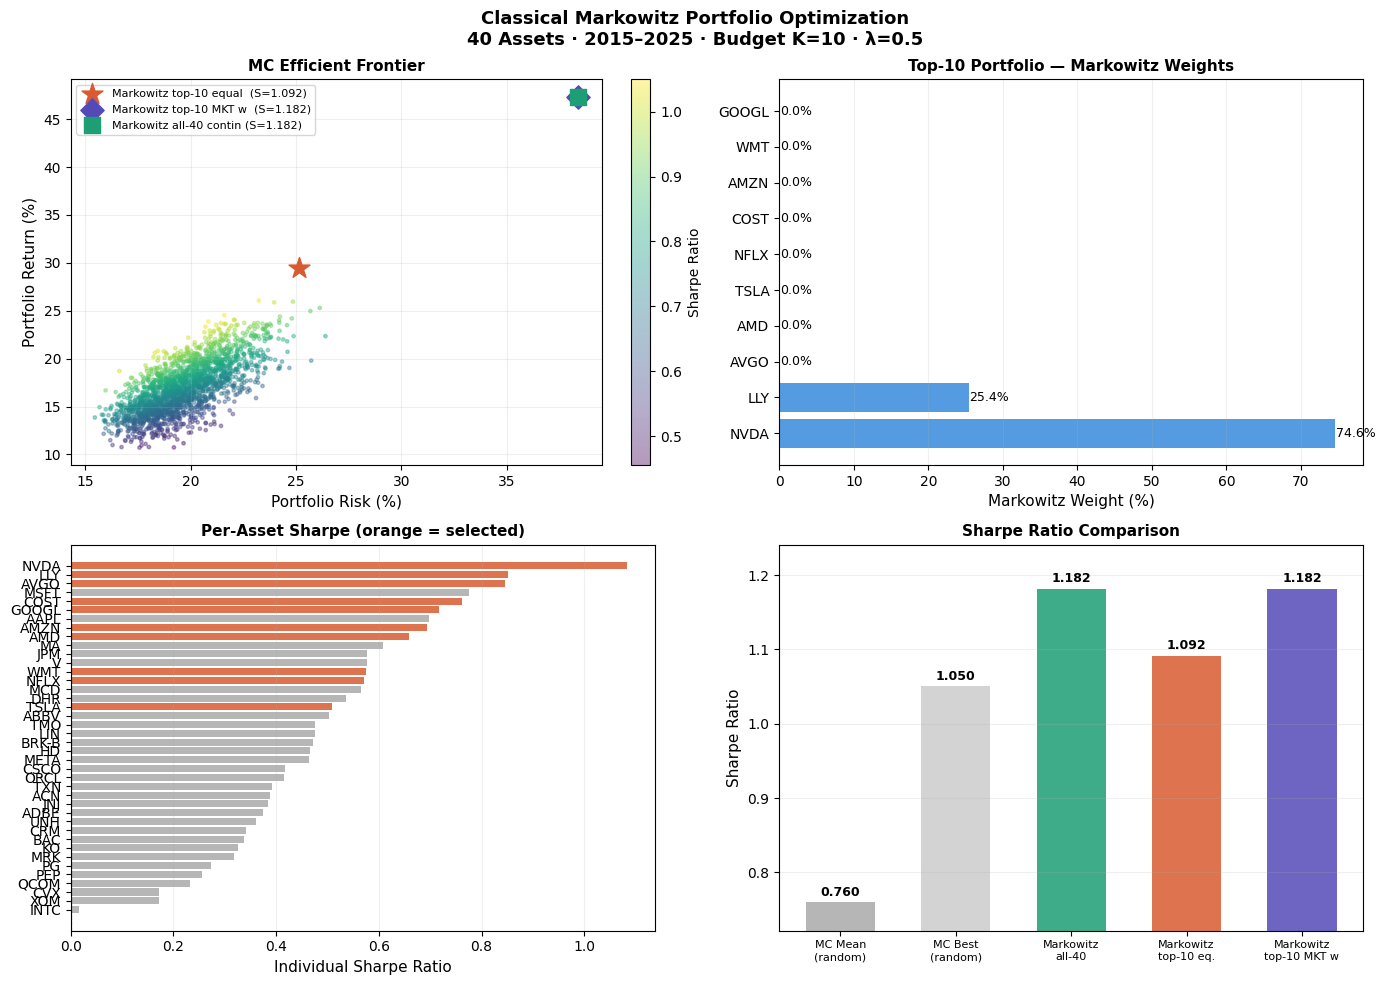

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Efficient Frontier ────────────────────────────────────
ax = axes[0, 0]
sc = ax.scatter(mc_risk, mc_ret, c=mc_sharpe, cmap='viridis', s=6, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio', fraction=0.04)

markers = [
    (mkt_binary,    '#D85A30', '*', 250, f"Markowitz top-10 equal  (S={mkt_binary['sharpe']:.3f})"),
    (mkt_top_w,     '#534AB7', 'D', 140, f"Markowitz top-10 MKT w  (S={mkt_top_w['sharpe']:.3f})"),
    (mkt_continuous,'#1D9E75', 's', 120, f"Markowitz all-40 contin (S={mkt_continuous['sharpe']:.3f})"),
]
for s, col, mrk, sz, lbl in markers:
    ax.scatter(s['risk']*100, s['return']*100, s=sz, c=col,
               marker=mrk, zorder=7, label=lbl)

ax.set_xlabel('Portfolio Risk (%)', fontsize=11)
ax.set_ylabel('Portfolio Return (%)', fontsize=11)
ax.set_title('MC Efficient Frontier', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# ── Plot 2: Asset weights bar chart ──────────────────────────────
ax = axes[0, 1]
tickers_top = [TICKERS[i] for i in top10_idx]
w_pct       = top_w * 100
bars = ax.barh(tickers_top, w_pct, color='#378ADD', alpha=0.85)
for bar, v in zip(bars, w_pct):
    ax.text(v + 0.1, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Markowitz Weight (%)', fontsize=11)
ax.set_title('Top-10 Portfolio — Markowitz Weights', fontsize=11, fontweight='bold')
ax.grid(True, axis='x', alpha=0.2)

# ── Plot 3: Individual asset Sharpe ──────────────────────────────
ax = axes[1, 0]
sorted_idx = np.argsort(individual_sharpe)
colors_bar = ['#D85A30' if i in top10_idx else '#AAAAAA' for i in sorted_idx]
ax.barh([TICKERS[i] for i in sorted_idx], individual_sharpe[sorted_idx],
        color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Individual Sharpe Ratio', fontsize=11)
ax.set_title('Per-Asset Sharpe (orange = selected)', fontsize=11, fontweight='bold')
ax.grid(True, axis='x', alpha=0.2)

# ── Plot 4: Sharpe comparison bar ────────────────────────────────
ax = axes[1, 1]
labels_cmp = ['MC Mean\n(random)', 'MC Best\n(random)',
               'Markowitz\nall-40', 'Markowitz\ntop-10 eq.',
               'Markowitz\ntop-10 MKT w']
sharpe_cmp = [mc_sharpe.mean(), mc_sharpe.max(),
              mkt_continuous['sharpe'], mkt_binary['sharpe'], mkt_top_w['sharpe']]
cols_cmp   = ['#AAAAAA','#CCCCCC','#1D9E75','#D85A30','#534AB7']
b = ax.bar(labels_cmp, sharpe_cmp, color=cols_cmp, alpha=0.85, width=0.6)
for bar, v in zip(b, sharpe_cmp):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Sharpe Ratio Comparison', fontsize=11, fontweight='bold')
ax.set_ylim(bottom=min(sharpe_cmp)*0.95)
ax.grid(True, axis='y', alpha=0.2)
ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Classical Markowitz Portfolio Optimization\n'
             f'40 Assets · 2015–2025 · Budget K={BUDGET} · λ={LAMBDA}',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


---
### 1.7 Final Summary

In [10]:
# ── Full Summary ──────────────────────────────────────────────────
print("=" * 70)
print("  CLASSICAL MARKOWITZ — FINAL SUMMARY")
print(f"  Dataset  : {N} assets · {T} days · {dates[0]} → {dates[-1]}")
print(f"  λ={LAMBDA}  K={BUDGET}  Risk-free={RISK_FREE*100:.1f}%")
print("=" * 70)

print(f"\n  OPTIMAL PORTFOLIO  (top-{BUDGET} by Markowitz weight, equal-weight eval)")
print(f"  Assets   : {', '.join(mkt_binary['tickers'])}")
print(f"  Return   : {mkt_binary['return']*100:.3f}%  (annualised)")
print(f"  Risk     : {mkt_binary['risk']*100:.3f}%  (annualised std-dev)")
print(f"  Sharpe   : {mkt_binary['sharpe']:.4f}")
print(f"  Obj H    : {mkt_binary['obj']:.6f}")

print(f"\n  HOW IT RANKS:")
print(f"  MC mean Sharpe  : {mc_sharpe.mean():.4f}  (avg random portfolio)")
print(f"  MC best Sharpe  : {mc_sharpe.max():.4f}  (best of 2000 random)")
print(f"  Markowitz Sharpe: {mkt_binary['sharpe']:.4f}  ← optimised")
pct = np.mean(mc_sharpe < mkt_binary['sharpe']) * 100
print(f"  Beats {pct:.1f}% of all random portfolios")

print(f"\n  SHARPE FORMULA:")
print(f"  Sharpe = (Return − Risk-free) / Risk")
print(f"         = ({mkt_binary['return']*100:.3f}% − {RISK_FREE*100:.1f}%) / {mkt_binary['risk']*100:.3f}%")
print(f"         = {mkt_binary['return']-RISK_FREE:.4f} / {mkt_binary['risk']:.4f}")
print(f"         = {mkt_binary['sharpe']:.4f}")
print("=" * 70)


  CLASSICAL MARKOWITZ — FINAL SUMMARY
  Dataset  : 40 assets · 2765 days · 2015-01-02 → 2025-12-30
  λ=0.5  K=10  Risk-free=2.0%

  OPTIMAL PORTFOLIO  (top-10 by Markowitz weight, equal-weight eval)
  Assets   : NVDA, LLY, AVGO, AMD, TSLA, NFLX, COST, AMZN, WMT, GOOGL
  Return   : 29.433%  (annualised)
  Risk     : 25.128%  (annualised std-dev)
  Sharpe   : 1.0917
  Obj H    : -0.115593

  HOW IT RANKS:
  MC mean Sharpe  : 0.7597  (avg random portfolio)
  MC best Sharpe  : 1.0502  (best of 2000 random)
  Markowitz Sharpe: 1.0917  ← optimised
  Beats 100.0% of all random portfolios

  SHARPE FORMULA:
  Sharpe = (Return − Risk-free) / Risk
         = (29.433% − 2.0%) / 25.128%
         = 0.2743 / 0.2513
         = 1.0917


---
## 2. Quantum-enhanced Markowitz Portfolio Optimization

Four progressive methods — each adds one layer on top of the previous:

| # | Method | Optimizer | Hamiltonian | Aggregation |
|---|--------|-----------|-------------|-------------|
| 1 | QAOA only | COBYLA | Standard | Expectation |
| 2 | QAOA + DRO-CVaR | COBYLA | Delage-Ye worst-case | CVaR 10% |
| 3 | QAOA + Two-Phase Hybrid + VQE warm-start + DY-DRO | DA+COBYLA | Delage-Ye worst-case | CVaR 10% |
| 4 | 3-Stage: QAOA+SPSA → Quantum Weight Opt → DY-DRO | SPSA+DA+COBYLA | Delage-Ye worst-case | CVaR 10% |


In [11]:
import os
from qiskit.circuit.library import TwoLocal, QAOAAnsatz
from qiskit_algorithms import SamplingVQE
from qiskit_algorithms.optimizers import COBYLA, Optimizer, OptimizerResult
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.translators import to_ising
import cvxpy as cp

# ── Quantum constants ──────────────────────────────────────────────────
N_Q        = 12      # quantum candidate pool  (> BUDGET)
BUDGET_Q   = 5       # assets selected by quantum solver
LAMBDA_Q   = 0.5     # risk-return trade-off
SHOTS_OPT  = 2048    # shots inside optimizer loop
SHOTS_DEC  = 4096    # shots for final decode
ALPHA_CVAR = 0.1     # CVaR tail (worst 10%)
REPS       = 1       # QAOA / VQE repetitions
BETA_DRO   = 0.05    # DRO confidence (95%)
T_OBS      = log_ret.shape[0]

# ── Pre-select top N_Q by Markowitz QP weight ─────────────────────────
q_sub_idx   = np.argsort(w_opt)[-N_Q:][::-1]
sub_mu      = mu[q_sub_idx]
sub_cov     = cov[np.ix_(q_sub_idx, q_sub_idx)]
sub_tickers = [TICKERS[i] for i in q_sub_idx]
print(f"Quantum pool ({N_Q} assets): {sub_tickers}")

# ── Hamiltonian builder ────────────────────────────────────────────────
def make_operator(s_mu, s_cov):
    po   = PortfolioOptimization(expected_returns=s_mu, covariances=s_cov,
                                 risk_factor=LAMBDA_Q, budget=BUDGET_Q)
    qubo = QuadraticProgramToQubo().convert(po.to_quadratic_program())
    return to_ising(qubo)   # (SparsePauliOp, float offset)

operator_std, offset_std = make_operator(sub_mu, sub_cov)
print(f"Hamiltonian: {operator_std.num_qubits} qubits, {len(operator_std)} Pauli terms")

# ── Decode quasi-distribution → portfolio ──────────────────────────────
def decode(eigenstate, n, sub_idx, budget):
    if hasattr(eigenstate, 'binary_probabilities'):
        dist = {int(k, 2): v for k, v in eigenstate.binary_probabilities().items()}
    else:
        dist = dict(eigenstate)
    for state_int, _ in sorted(dist.items(), key=lambda x: -x[1]):
        bits = format(state_int, f'0{n}b')[::-1]
        sel  = [sub_idx[i] for i, b in enumerate(bits) if b == '1']
        if len(sel) == budget:
            return np.array(sel)
    return np.array(sub_idx[:budget])   # fallback

# ── Equal-weight portfolio stats ───────────────────────────────────────
def q_stats(idx):
    """Portfolio stats using Markowitz-optimal weights for selected subset."""
    idx      = np.array(idx)
    k        = len(idx)
    s_mu     = mu[idx]
    s_cov    = cov[np.ix_(idx, idx)]
    # Markowitz QP on the selected subset
    w_var    = cp.Variable(k, nonneg=True)
    prob_sub = cp.Problem(
        cp.Minimize(LAMBDA_Q * cp.quad_form(w_var, s_cov) - (1-LAMBDA_Q) * s_mu @ w_var),
        [cp.sum(w_var) == 1]
    )
    prob_sub.solve(solver=cp.CLARABEL, verbose=False)
    w = w_var.value if prob_sub.status == 'optimal' and w_var.value is not None         else np.ones(k) / k
    r = float(w @ s_mu)
    v = float(w @ s_cov @ w)
    return {'return': r, 'risk': np.sqrt(v),
            'sharpe': (r - RISK_FREE) / np.sqrt(v),
            'weights': w,
            'tickers': [TICKERS[i] for i in idx]}

# ── cuStateVec availability check ─────────────────────────────────────
def _check_custatevec_cpu():
    try:
        from qiskit import QuantumCircuit
        sim = AerSimulator(method='statevector', device='CPU', cuStateVec_enable=True)
        qc  = QuantumCircuit(2); qc.h(0); qc.cx(0,1); qc.measure_all()
        sim.run(qc, shots=8).result()
        return True
    except Exception:
        return False

CUSTATEVEC_AVAILABLE = _check_custatevec_cpu()
N_THREADS = os.cpu_count()
print(f"cuStateVec CPU available : {CUSTATEVEC_AVAILABLE}")
print(f"CPU threads              : {N_THREADS}")

# ── Shared sampler (cuStateVec CPU if available, else default Aer) ─────
sampler = AerSampler()
if CUSTATEVEC_AVAILABLE:
    sampler.set_options(
        shots                          = SHOTS_OPT,
        seed_simulator                 = 42,
        method                         = 'statevector',
        device                         = 'CPU',
        cuStateVec_enable              = True,
        max_parallel_threads           = N_THREADS,
        max_parallel_experiments       = 1,
        statevector_parallel_threshold = 14,
    )
    print(f"Sampler backend : cuStateVec CPU  ({N_THREADS} threads)")
else:
    sampler.set_options(shots=SHOTS_OPT, seed_simulator=42)
    print("Sampler backend : Aer default statevector (cuStateVec not available)")
print("Setup complete.")


Quantum pool (12 assets): ['NVDA', 'LLY', 'AVGO', 'AMD', 'TSLA', 'NFLX', 'COST', 'AMZN', 'WMT', 'GOOGL', 'ABBV', 'AAPL']
Hamiltonian: 12 qubits, 78 Pauli terms
cuStateVec CPU available : True
CPU threads              : 24
Sampler backend : cuStateVec CPU  (24 threads)
Setup complete.


### Method 1 — QAOA only
`QAOAAnsatz` · COBYLA · standard expectation value


In [12]:
ansatz_qaoa = QAOAAnsatz(operator_std, reps=REPS)
print(f"QAOA ansatz: {ansatz_qaoa.num_parameters} parameters (beta + gamma per rep)")

vqe_m2 = SamplingVQE(sampler=sampler, ansatz=ansatz_qaoa,
                     optimizer=COBYLA(maxiter=300),
                     initial_point=np.zeros(ansatz_qaoa.num_parameters))

t0 = time.perf_counter()
res_m2 = vqe_m2.compute_minimum_eigenvalue(operator_std)
t_m2   = time.perf_counter() - t0

sel_m2   = decode(res_m2.eigenstate, N_Q, q_sub_idx, BUDGET_Q)
stats_m2 = q_stats(sel_m2)

print(f"\nMethod 1 — QAOA only")
print(f"  Energy    : {res_m2.eigenvalue:.6f}")
print(f"  Wall time : {t_m2:.2f}s  |  Iterations: {res_m2.cost_function_evals}")
print(f"  Selected  : {stats_m2['tickers']}")
print(f"  Return    : {stats_m2['return']*100:.2f}%  Risk: {stats_m2['risk']*100:.2f}%  Sharpe: {stats_m2['sharpe']:.4f}")


QAOA ansatz: 2 parameters (beta + gamma per rep)

Method 1 — QAOA only
  Energy    : -0.363962
  Wall time : 0.80s  |  Iterations: 7
  Selected  : ['LLY', 'NFLX', 'WMT', 'GOOGL', 'ABBV']
  Return    : 25.94%  Risk: 23.77%  Sharpe: 1.0071


### Method 2 — QAOA + DRO-CVaR
**DRO (Delage-Ye 2010):** calibrate worst-case μ\* and Σ\* from data → more robust Hamiltonian.  
**CVaR (Barkoutsos 2020):** aggregate over the worst-α tail of the sampling distribution.

**VQE warm-start:** a short VQE run on the DY-DRO Hamiltonian provides a better initial β/γ for QAOA.


In [13]:
# ── Delage-Ye γ calibration ──────────────────────────────────────────
n_sub   = N_Q
GAMMA_1 = (np.sqrt(n_sub) + np.sqrt(2*np.log(1/BETA_DRO)))**2 / T_OBS
GAMMA_2 = 1 + np.sqrt((n_sub + 2*np.sqrt(n_sub*np.log(2/BETA_DRO))
                        + 2*np.log(2/BETA_DRO)) / (T_OBS - 1))
print(f"DRO: γ₁={GAMMA_1:.5f}  γ₂={GAMMA_2:.5f}  (T={T_OBS}, n={n_sub}, β={BETA_DRO})")

# ── SOCP: find DY-optimal weights ────────────────────────────────────
Sigma_half = np.linalg.cholesky(sub_cov + 1e-8*np.eye(n_sub))
w_dy = cp.Variable(n_sub, nonneg=True)
t_dy = cp.Variable(nonneg=True)
dy_prob = cp.Problem(
    cp.Minimize(LAMBDA_Q*GAMMA_2*cp.quad_form(w_dy, sub_cov)
                - (1-LAMBDA_Q)*sub_mu@w_dy
                + (1-LAMBDA_Q)*np.sqrt(GAMMA_1)*t_dy),
    [cp.sum(w_dy)==1, cp.norm(Sigma_half@w_dy, 2)<=t_dy, w_dy<=1]
)
dy_prob.solve(solver=cp.CLARABEL, verbose=False)
w_dy_opt = w_dy.value

# ── Worst-case moment parameters ──────────────────────────────────────
sw       = Sigma_half @ w_dy_opt
mu_DY    = sub_mu - np.sqrt(GAMMA_1) * (sub_cov @ w_dy_opt) / np.linalg.norm(sw)
Sigma_DY = GAMMA_2 * sub_cov
print(f"Worst-case μ* range : {mu_DY.min():.4f} → {mu_DY.max():.4f}  (original: {sub_mu.min():.4f} → {sub_mu.max():.4f})")

# ── DRO Hamiltonian ───────────────────────────────────────────────────
operator_dy, offset_dy = make_operator(mu_DY, Sigma_DY)


# ── VQE warm-start to initialize QAOA β/γ on DY-DRO Hamiltonian ─────
print('Computing VQE warm-start for QAOA initial point ...')
vqe_ws_m2   = SamplingVQE(
    sampler=sampler,
    ansatz=TwoLocal(N_Q, 'ry', 'cx', reps=1, entanglement='linear'),
    optimizer=COBYLA(maxiter=150))
res_ws_m2   = vqe_ws_m2.compute_minimum_eigenvalue(operator_dy)
gamma_ws_m2 = float(np.clip(-res_ws_m2.eigenvalue / (2 * N_Q), -np.pi, np.pi))
qaoa_ip_ws  = np.array([np.pi / 4] * REPS + [gamma_ws_m2] * REPS)
print(f'  VQE E={res_ws_m2.eigenvalue:.4f}  β={np.pi/4:.3f}  γ={gamma_ws_m2:.3f}')
# ── QAOA with CVaR on DRO Hamiltonian ────────────────────────────────
ansatz_m4 = QAOAAnsatz(operator_dy, reps=REPS)
vqe_m4 = SamplingVQE(sampler=sampler, ansatz=ansatz_m4,
                     optimizer=COBYLA(maxiter=300),
                     initial_point=qaoa_ip_ws,
                     aggregation=ALPHA_CVAR)     # CVaR 10%

t0 = time.perf_counter()
res_m4 = vqe_m4.compute_minimum_eigenvalue(operator_dy)
t_m4   = time.perf_counter() - t0

sel_m4   = decode(res_m4.eigenstate, N_Q, q_sub_idx, BUDGET_Q)
stats_m4 = q_stats(sel_m4)

print(f"\nMethod 2 — QAOA + DRO-CVaR (α={ALPHA_CVAR})")
print(f"  Energy    : {res_m4.eigenvalue:.6f}")
print(f"  Wall time : {t_m4:.2f}s  |  Iterations: {res_m4.cost_function_evals}")
print(f"  Selected  : {stats_m4['tickers']}")
print(f"  Return    : {stats_m4['return']*100:.2f}%  Risk: {stats_m4['risk']*100:.2f}%  Sharpe: {stats_m4['sharpe']:.4f}")


DRO: γ₁=0.01264  γ₂=1.10876  (T=2764, n=12, β=0.05)
Worst-case μ* range : 0.1390 → 0.5092  (original: 0.1434 → 0.5435)
Computing VQE warm-start for QAOA initial point ...
  VQE E=-28.9418  β=0.785  γ=1.206

Method 2 — QAOA + DRO-CVaR (α=0.1)
  Energy    : -34.508825
  Wall time : 1.44s  |  Iterations: 31
  Selected  : ['LLY', 'NFLX', 'AMZN', 'ABBV', 'AAPL']
  Return    : 26.15%  Risk: 23.69%  Sharpe: 1.0192


### Method 3 — QAOA + Two-Phase Hybrid Optimizer + VQE warm-start + DY-DRO

**Two-Phase Hybrid Optimizer (DA + COBYLA)** — two-phase classical optimizer:
- **Phase 1 · Dual Annealing** (global): escapes local minima, explores full parameter landscape
- **Phase 2 · COBYLA** (local): refines the Phase 1 solution to high precision

Combined with:
- **VQE warm-start** on the DY-DRO Hamiltonian → better initial β/γ for QAOA
- **DY-DRO Hamiltonian** (worst-case μ\*, Σ\*) for distributional robustness
- **CVaR 10%** tail aggregation for risk-aware sampling


In [14]:
class TwoPhaseOptimizer(Optimizer):
    """
    Two-Phase Hybrid Optimizer (DA + COBYLA):
      Phase 1 — scipy.dual_annealing (global, avoids local minima)
      Phase 2 — COBYLA (local refinement from Phase 1 result)
    Takes the best of both phases.
    """
    def __init__(self, maxiter_p1=300, maxiter_p2=200):
        super().__init__()
        self._maxiter_p1 = maxiter_p1
        self._maxiter_p2 = maxiter_p2

    @property
    def settings(self):
        return {'maxiter_p1': self._maxiter_p1, 'maxiter_p2': self._maxiter_p2}

    def get_support_level(self):
        from qiskit_algorithms.optimizers import OptimizerSupportLevel
        return {
            'gradient':      OptimizerSupportLevel.ignored,
            'bounds':        OptimizerSupportLevel.ignored,
            'initial_point': OptimizerSupportLevel.supported,
        }

    def minimize(self, fun, x0, jac=None, bounds=None):
        from scipy.optimize import dual_annealing, minimize as sp_min

        bds = [(float(b[0]) if b[0] is not None else -np.pi,
                float(b[1]) if b[1] is not None else  np.pi)
               for b in bounds] if bounds is not None else [(-np.pi, np.pi)] * len(x0)

        # Phase 1: Dual Annealing (global)
        print(f"    Phase 1 · Dual Annealing (maxiter={self._maxiter_p1}) ...", end='', flush=True)
        res1 = dual_annealing(fun, bds, x0=x0, maxiter=self._maxiter_p1, seed=42,
                              minimizer_kwargs={'method': 'COBYLA'})
        print(f" E={res1.fun:.5f}  nfev={res1.nfev}")

        # Phase 2: COBYLA (local refinement)
        print(f"    Phase 2 · COBYLA (maxiter={self._maxiter_p2}) ...", end='', flush=True)
        res2 = sp_min(fun, res1.x, method='COBYLA',
                      options={'maxiter': self._maxiter_p2, 'rhobeg': 0.1})
        print(f" E={res2.fun:.5f}  nfev={res2.nfev}")

        # Take best of both phases
        if res2.fun <= res1.fun:
            best_x, best_fun = res2.x, float(res2.fun)
            print(f"    → Phase 2 (COBYLA) wins: E={best_fun:.5f}")
        else:
            best_x, best_fun = res1.x, float(res1.fun)
            print(f"    → Phase 1 (Dual Annealing) wins: E={best_fun:.5f}")

        r = OptimizerResult()
        r.x   = np.array(best_x)
        r.fun  = best_fun
        r.nfev = res1.nfev + res2.nfev
        return r


# Step 1: VQE warm-start on DY-DRO Hamiltonian
print("Step 1 — VQE warm-start on DY-DRO Hamiltonian ...")
ansatz_ws = TwoLocal(N_Q, 'ry', 'cx', reps=REPS, entanglement='linear')
vqe_ws    = SamplingVQE(sampler=sampler, ansatz=ansatz_ws, optimizer=COBYLA(maxiter=200))

t0_ws  = time.perf_counter()
res_ws = vqe_ws.compute_minimum_eigenvalue(operator_dy)
t_ws   = time.perf_counter() - t0_ws
print(f"  VQE on DY-DRO: E={res_ws.eigenvalue:.5f}  ({t_ws:.1f}s)")

gamma_m6   = float(np.clip(-res_ws.eigenvalue / (2 * N_Q), -np.pi, np.pi))
beta_m6    = np.pi / 4
qaoa_ip_m6 = np.array([beta_m6] * REPS + [gamma_m6] * REPS)
print(f"  QAOA warm-start: β={beta_m6:.3f}  γ={gamma_m6:.3f}")

# Step 2: QAOA + SPA on DY-DRO Hamiltonian
print("\nStep 2 — QAOA + SPA (Dual Annealing → COBYLA) ...")
ansatz_m6 = QAOAAnsatz(operator_dy, reps=REPS)
vqe_m6 = SamplingVQE(
    sampler=sampler,
    ansatz=ansatz_m6,
    optimizer=TwoPhaseOptimizer(maxiter_p1=300, maxiter_p2=200),
    initial_point=qaoa_ip_m6,
    aggregation=ALPHA_CVAR
)

t0 = time.perf_counter()
res_m6 = vqe_m6.compute_minimum_eigenvalue(operator_dy)
t_m6   = time.perf_counter() - t0

sel_m6   = decode(res_m6.eigenstate, N_Q, q_sub_idx, BUDGET_Q)
stats_m6 = q_stats(sel_m6)

print(f"\nMethod 3 — QAOA + Two-Phase Hybrid + VQE warm-start + DY-DRO")
print(f"  Final energy : {res_m6.eigenvalue:.6f}")
print(f"  Total nfev   : {res_m6.cost_function_evals}")
print(f"  Wall time    : {t_ws:.1f}s (VQE) + {t_m6:.1f}s (SPA) = {t_ws+t_m6:.1f}s total")
print(f"  Selected     : {stats_m6['tickers']}")
print(f"  Return       : {stats_m6['return']*100:.2f}%  Risk: {stats_m6['risk']*100:.2f}%  Sharpe: {stats_m6['sharpe']:.4f}")


Step 1 — VQE warm-start on DY-DRO Hamiltonian ...
  VQE on DY-DRO: E=-30.52124  (5.0s)
  QAOA warm-start: β=0.785  γ=1.272

Step 2 — QAOA + SPA (Dual Annealing → COBYLA) ...
    Phase 1 · Dual Annealing (maxiter=300) ... E=-34.53444  nfev=1312
    Phase 2 · COBYLA (maxiter=200) ... E=-34.53444  nfev=20
    → Phase 2 (COBYLA) wins: E=-34.53444

Method 3 — QAOA + Two-Phase Hybrid + VQE warm-start + DY-DRO
  Final energy : -34.534442
  Total nfev   : 1332
  Wall time    : 5.0s (VQE) + 51.3s (SPA) = 56.3s total
  Selected     : ['LLY', 'AVGO', 'COST', 'AMZN', 'ABBV']
  Return       : 31.06%  Risk: 27.05%  Sharpe: 1.0743


### Method 4 — 3-Stage Pipeline: QAOA+SPSA → Quantum Weight Opt → DY-DRO

| Stage | Role | Method |
|-------|------|--------|
| **1 — Selection** | Which K assets to hold | QAOA + SPSA on DY-DRO Hamiltonian |
| **2 — Weights** | How much % to allocate each | VQE (Ry circuit) + Dual Annealing + COBYLA |
| **3 — Robustness** | Improve Sharpe under uncertainty | DY-DRO(which is a SOCP: Second-Order Cone Program on selected K assets |

**Key idea:** Selection and weight allocation are separated — QAOA solves the binary combinatorial problem, VQE solves the continuous weight problem, DRO makes both robust.


In [15]:
from qiskit_algorithms.optimizers import SPSA

from qiskit.circuit import QuantumCircuit, ParameterVector
from scipy.optimize import dual_annealing, minimize as sp_min

print("=" * 65)
print("METHOD 4 — 3-STAGE PIPELINE")
print("=" * 65)

# ══════════════════════════════════════════════════════════════
# STAGE 1 — ASSET SELECTION  (QAOA + SPSA + DY-DRO Hamiltonian)
# ══════════════════════════════════════════════════════════════
print("\nSTAGE 1: Asset selection via QAOA + SPSA")
print("-" * 45)

spsa_sel   = SPSA(maxiter=300, learning_rate=0.1, perturbation=0.05)
ansatz_sel = QAOAAnsatz(operator_dy, reps=REPS)

# VQE warm-start for QAOA initial β/γ (run on DY-DRO Hamiltonian)
vqe_init = SamplingVQE(
    sampler=sampler,
    ansatz=TwoLocal(N_Q, 'ry', 'cx', reps=1, entanglement='linear'),
    optimizer=COBYLA(maxiter=150)
)
res_init   = vqe_init.compute_minimum_eigenvalue(operator_dy)
gamma_s1   = float(np.clip(-res_init.eigenvalue / (2 * N_Q), -np.pi, np.pi))
ip_s1      = np.array([np.pi / 4] * REPS + [gamma_s1] * REPS)

vqe_sel = SamplingVQE(
    sampler=sampler, ansatz=ansatz_sel,
    optimizer=spsa_sel, initial_point=ip_s1,
    aggregation=ALPHA_CVAR
)
t0 = time.perf_counter()
res_sel = vqe_sel.compute_minimum_eigenvalue(operator_dy)
t_s1    = time.perf_counter() - t0

selected  = decode(res_sel.eigenstate, N_Q, q_sub_idx, BUDGET_Q)
sel_names = [TICKERS[i] for i in selected]
print(f"  Selection energy : {res_sel.eigenvalue:.5f}")
print(f"  Wall time        : {t_s1:.1f}s")
print(f"  Selected assets  : {sel_names}")

# Positions of selected assets within the N_Q sub-space
sel_pos    = [int(np.where(q_sub_idx == idx)[0][0]) for idx in selected]
K          = len(selected)

# DRO sub-parameters for the selected K assets
mu_sel_dy  = mu_DY[sel_pos]           # worst-case returns
cov_sel_dy = Sigma_DY[np.ix_(sel_pos, sel_pos)]  # worst-case covariance
mu_sel_std = sub_mu[sel_pos]          # historical returns (for comparison)
cov_sel_std = sub_cov[np.ix_(sel_pos, sel_pos)]

# ══════════════════════════════════════════════════════════════
# STAGE 2 — WEIGHT ALLOCATION  (Quantum-Parameterized Weight Optimizer)
# ══════════════════════════════════════════════════════════════
print(f"\nSTAGE 2: Quantum-Parameterized Weight Optimizer (Ry circuit + DA + COBYLA)")
print("-" * 45)

# ── Quantum-parameterized weight circuit ────────────────────────
# This is NOT standard VQE (which minimises ⟨ψ|H|ψ⟩ for a quantum H).
# Instead: Ry circuit parameterises weights via P(|1⟩) ∝ weight,
# and a classical Markowitz cost is minimised — a quantum-inspired heuristic.
# K Ry rotations: P(|1⟩ on qubit i) = sin²(θᵢ/2) ∝ weight of asset i
theta_vec = ParameterVector('θ', K)
wt_qc     = QuantumCircuit(K)
for i in range(K):
    wt_qc.ry(theta_vec[i], i)
for i in range(K - 1):          # entangle adjacent qubits
    wt_qc.cx(i, i + 1)
wt_qc.measure_all()

def circuit_to_weights(theta_vals):
    """Run Ry circuit → marginal P(|1⟩) per qubit → normalised weights."""
    bound = wt_qc.assign_parameters(dict(zip(theta_vec, theta_vals)))
    job   = sampler.run([bound])
    dist  = job.result().quasi_dists[0]
    p = np.zeros(K)
    for state_int, prob in dist.items():
        bits = format(state_int, f'0{K}b')[::-1]   # little-endian
        for qi, b in enumerate(bits):
            if b == '1':
                p[qi] += max(prob, 0.0)
    total = p.sum()
    return p / total if total > 1e-10 else np.ones(K) / K

def weight_cost(theta_vals):
    """Markowitz objective using DRO worst-case parameters."""
    w   = circuit_to_weights(theta_vals)
    ret = float(w @ mu_sel_dy)
    var = float(w @ cov_sel_dy @ w)
    return LAMBDA_Q * var - (1 - LAMBDA_Q) * ret

# Initial angles: π/4 → sin²(π/8)≈0.15 per qubit (roughly equal weights)
theta0      = np.ones(K) * (np.pi / 4)
bounds_wt   = [(0.01, np.pi - 0.01)] * K

# Phase 1: Dual Annealing (global)
print("  Phase 1 · Dual Annealing ...", end='', flush=True)
t0   = time.perf_counter()
res_da = dual_annealing(weight_cost, bounds_wt, x0=theta0,
                        maxiter=200, seed=42,
                        minimizer_kwargs={'method': 'COBYLA'})
t_da = time.perf_counter() - t0
print(f" cost={res_da.fun:.5f}  nfev={res_da.nfev}  ({t_da:.1f}s)")

# Phase 2: COBYLA (local refinement)
print("  Phase 2 · COBYLA     ...", end='', flush=True)
t0   = time.perf_counter()
res_co = sp_min(weight_cost, res_da.x, method='COBYLA',
                options={'maxiter': 300, 'rhobeg': 0.05})
t_co = time.perf_counter() - t0
print(f" cost={res_co.fun:.5f}  nfev={res_co.nfev}  ({t_co:.1f}s)")
t_s2 = t_da + t_co

best_theta  = res_co.x if res_co.fun <= res_da.fun else res_da.x
w_qpw       = circuit_to_weights(best_theta)

print(f"\n  VQE weight allocation:")
for name, wi in zip(sel_names, w_qpw):
    bar = '█' * int(wi * 40)
    print(f"    {name:<8} {wi*100:5.1f}%  {bar}")

# ══════════════════════════════════════════════════════════════
# STAGE 3 — DRO SHARPE IMPROVEMENT  (DY-DRO SOCP on K assets)
# ══════════════════════════════════════════════════════════════
print(f"\nSTAGE 3: DY-DRO Sharpe improvement (SOCP on {K} selected assets)")
print("-" * 45)

# Sharpe before DRO (VQE weights, historical parameters)
r_pre  = float(w_qpw @ mu_sel_std)
v_pre  = float(w_qpw @ cov_sel_std @ w_qpw)
sh_pre = (r_pre - RISK_FREE) / np.sqrt(v_pre)

# DY-DRO SOCP restricted to selected K assets
Sh_k   = np.linalg.cholesky(cov_sel_dy + 1e-8 * np.eye(K))
w_dro  = cp.Variable(K, nonneg=True)
t_cone = cp.Variable(nonneg=True)
dro_k  = cp.Problem(
    cp.Minimize(LAMBDA_Q * GAMMA_2 * cp.quad_form(w_dro, cov_sel_dy)
                - (1 - LAMBDA_Q) * mu_sel_dy @ w_dro
                + (1 - LAMBDA_Q) * np.sqrt(GAMMA_1) * t_cone),
    [cp.sum(w_dro) == 1,
     cp.norm(Sh_k @ w_dro, 2) <= t_cone,
     w_dro <= 1]
)
t0 = time.perf_counter()
dro_k.solve(solver=cp.CLARABEL, verbose=False)
t_s3 = time.perf_counter() - t0
w_dro_refined = w_dro.value

# Sharpe after DRO
r_post  = float(w_dro_refined @ mu_sel_std)
v_post  = float(w_dro_refined @ cov_sel_std @ w_dro_refined)
sh_post = (r_post - RISK_FREE) / np.sqrt(v_post)

print(f"  Sharpe before DRO (VQE weights)  : {sh_pre:.4f}")
print(f"  Sharpe after  DRO (SOCP refined) : {sh_post:.4f}  "
      f"({'▲ +' if sh_post>sh_pre else '▼ '}{abs(sh_post-sh_pre):.4f})")
print(f"\n  DRO-refined weight allocation:")
for name, wi_pre, wi_post in zip(sel_names, w_qpw, w_dro_refined):
    shift = wi_post - wi_pre
    arrow = f'+{shift*100:.1f}%' if shift >= 0 else f'{shift*100:.1f}%'
    print(f"    {name:<8}  VQE={wi_pre*100:5.1f}%  →  DRO={wi_post*100:5.1f}%  ({arrow})")

# Final portfolio stats (use DRO-refined weights)
stats_m8 = {
    'return': r_post,
    'risk'  : np.sqrt(v_post),
    'sharpe': sh_post,
    'tickers': sel_names
}
t_m8_total = t_s1 + t_s2 + t_s3

print(f"\n{'='*55}")
print(f"  METHOD 8 FINAL RESULT")
print(f"{'='*55}")
print(f"  Return  : {r_post*100:.2f}%")
print(f"  Risk    : {np.sqrt(v_post)*100:.2f}%")
print(f"  Sharpe  : {sh_post:.4f}")
print(f"  Time    : {t_s1:.1f}s (S1) + {t_s2:.1f}s (S2) + {t_s3:.2f}s (S3) "
      f"= {t_m8_total:.1f}s total")


METHOD 4 — 3-STAGE PIPELINE

STAGE 1: Asset selection via QAOA + SPSA
---------------------------------------------
  Selection energy : -34.43203
  Wall time        : 19.4s
  Selected assets  : ['LLY', 'AMD', 'TSLA', 'WMT', 'ABBV']

STAGE 2: Quantum-Parameterized Weight Optimizer (Ry circuit + DA + COBYLA)
---------------------------------------------
  Phase 1 · Dual Annealing ... cost=-0.09693  nfev=2206  (132.1s)
  Phase 2 · COBYLA     ... cost=-0.09693  nfev=31  (2.0s)

  VQE weight allocation:
    LLY       40.7%  ████████████████
    AMD       32.0%  ████████████
    TSLA       9.0%  ███
    WMT        9.0%  ███
    ABBV       9.4%  ███

STAGE 3: DY-DRO Sharpe improvement (SOCP on 5 selected assets)
---------------------------------------------
  Sharpe before DRO (VQE weights)  : 0.9960
  Sharpe after  DRO (SOCP refined) : 1.0491  (▲ +0.0532)

  DRO-refined weight allocation:
    LLY       VQE= 40.7%  →  DRO= 55.6%  (+14.9%)
    AMD       VQE= 32.0%  →  DRO= 19.7%  (-12.2%)
   

### Comparison — 4 Quantum Methods vs Classical Baseline


  QUANTUM vs CLASSICAL — 4-METHOD SCORECARD
  Method                             Return%    Risk%   Sharpe   ΔSharpe  Time(s)     Energy
-----------------------------------------------------------------------------------------------
  Classical (baseline)                47.34%   38.37%   1.1817 ─  0.0000       —          —
  1. QAOA                             25.94%   23.77%   1.0071 ▼  0.1746     0.8    -0.3640
  2. QAOA + DRO-CVaR                  26.15%   23.69%   1.0192 ▼  0.1625     1.4   -34.5088
  3. QAOA+TwoPhase+VQE+DY-DRO         31.06%   27.05%   1.0743 ▼  0.1074    56.3   -34.5344
  4. 3-Stage: QAOA+VQE+DRO            28.19%   24.97%   1.0491 ▼  0.1325   153.5          —

  Best quantum method : 3. QAOA+TwoPhase+VQE+DY-DRO  (Sharpe=1.0743)
  Classical baseline  : Sharpe=1.1817


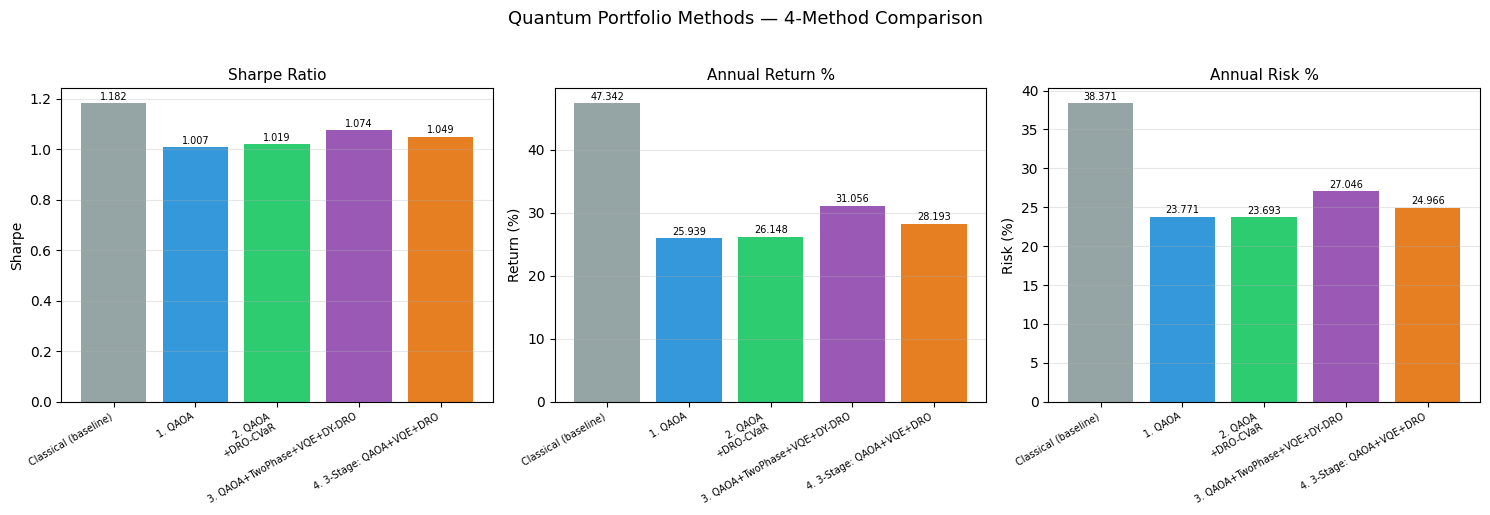

In [16]:
# Classical baseline: top-BUDGET_Q by Markowitz weight (equal weight)
cl_idx    = np.argsort(w_opt)[-BUDGET_Q:][::-1]
stats_cl  = q_stats(cl_idx)

methods = {
    'Classical (baseline)':            (stats_cl,  None,        None),
    '1. QAOA':                         (stats_m2,  t_m2,        res_m2.eigenvalue),
    '2. QAOA + DRO-CVaR':              (stats_m4,  t_m4,        res_m4.eigenvalue),
    '3. QAOA+TwoPhase+VQE+DY-DRO':    (stats_m6,  t_ws+t_m6,  res_m6.eigenvalue),
    '4. 3-Stage: QAOA+VQE+DRO':       (stats_m8,  t_m8_total,  None),
}

print('='*95)
print('  QUANTUM vs CLASSICAL — 4-METHOD SCORECARD')
print('='*95)
print(f"  {'Method':<32} {'Return%':>9} {'Risk%':>8} {'Sharpe':>8} {'ΔSharpe':>9} {'Time(s)':>8} {'Energy':>10}")
print('-'*95)
for name, (st, t, ev) in methods.items():
    ds  = st['sharpe'] - stats_cl['sharpe']
    flag = ('▲' if ds > 0 else ('─' if ds == 0 else '▼')) if t is not None else '─'
    t_s  = f"{t:>7.1f}" if t is not None else '      —'
    ev_s = f"{ev:>10.4f}" if ev is not None else '         —'
    print(f"  {name:<32} {st['return']*100:>8.2f}% {st['risk']*100:>7.2f}% "
          f"{st['sharpe']:>8.4f} {flag}{abs(ds):>8.4f} {t_s} {ev_s}")
print('='*95)

best_name = max([(n, s) for n, (s, t, _) in methods.items() if t is not None],
                key=lambda x: x[1]['sharpe'])
print(f"\n  Best quantum method : {best_name[0]}  (Sharpe={best_name[1]['sharpe']:.4f})")
print(f"  Classical baseline  : Sharpe={stats_cl['sharpe']:.4f}")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names  = list(methods.keys())
sharpe = [s['sharpe'] for s, _, _ in methods.values()]
rets   = [s['return']*100 for s, _, _ in methods.values()]
risks  = [s['risk']*100 for s, _, _ in methods.values()]
colors = ['#95a5a6', '#3498db', '#2ecc71', '#9b59b6', '#e67e22']

for ax, vals, title, ylabel in zip(
        axes,
        [sharpe, rets, risks],
        ['Sharpe Ratio', 'Annual Return %', 'Annual Risk %'],
        ['Sharpe', 'Return (%)', 'Risk (%)']):
    bars = ax.bar(range(len(names)), vals, color=colors)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' + ', '\n+') for n in names], fontsize=7, rotation=30, ha='right')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005*max(vals),
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Quantum Portfolio Methods — 4-Method Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'quantum_4method_comparison.png'), dpi=130, bbox_inches='tight')
plt.show()
